In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score


In [11]:
# Load dataset
path_to_data = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
col_names = [
    'age','workclass','fnlwgt','education','education-num','marital-status',
    'occupation','relationship','race','sex','capital-gain','capital-loss',
    'hours-per-week','native-country','income'
]
df = pd.read_csv(path_to_data, header=None, names=col_names)
# Clean string columns


In [12]:
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

# Features + target
raw_feature_cols = ['age','education-num','workclass','hours-per-week','sex','race']
X = pd.get_dummies(df[raw_feature_cols], drop_first=True)
y = df['income'].map(lambda val: 1 if val == '>50K' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)


C:\Users\apexf\AppData\Local\Temp\ipykernel_21388\626296162.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include=['object']).columns:


In [13]:
# Base estimator (decision stump)
decision_stump = DecisionTreeClassifier(max_depth=1)

# AdaBoost + GradientBoost
ada_classifier = AdaBoostClassifier(estimator=decision_stump)
grad_classifier = GradientBoostingClassifier()


In [14]:
# Fit + predict
ada_classifier.fit(X_train, y_train)
grad_classifier.fit(X_train, y_train)
y_pred_ada = ada_classifier.predict(X_test)
y_pred_grad = grad_classifier.predict(X_test)


In [15]:
# Metrics
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost F1 Score:", f1_score(y_test, y_pred_ada))
print("GradientBoost Accuracy:", accuracy_score(y_test, y_pred_grad))
print("GradientBoost F1 Score:", f1_score(y_test, y_pred_grad))


AdaBoost Accuracy: 0.8056095813286928
AdaBoost F1 Score: 0.4893788652863673
GradientBoost Accuracy: 0.8145153035111066
GradientBoost F1 Score: 0.5295950155763239


In [16]:
# Hyperparameter tuning for AdaBoost
n_estimators_list = [10, 30, 50, 70, 90]
param_grid = {"n_estimators": n_estimators_list}
grid = GridSearchCV(ada_classifier, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...(max_depth=1))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [10, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fittin

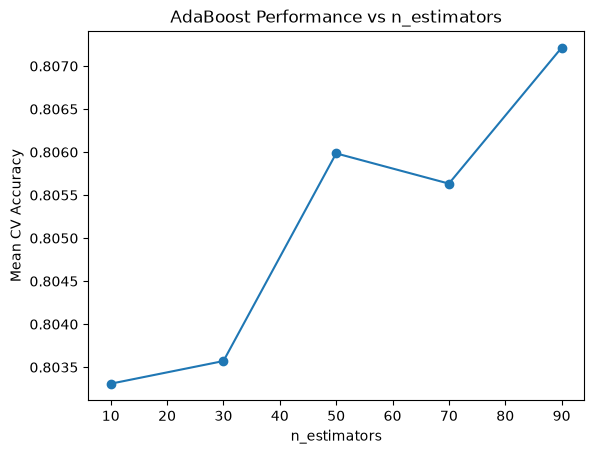

In [17]:
# Mean CV scores
ada_scores_list = grid.cv_results_['mean_test_score']

# Plot
plt.plot(n_estimators_list, ada_scores_list, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Mean CV Accuracy")
plt.title("AdaBoost Performance vs n_estimators")
plt.show()


In [18]:
# Best model evaluation
best_ada = grid.best_estimator_
y_pred_best = best_ada.predict(X_test)
print("Best n_estimators:", grid.best_params_['n_estimators'])
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Test F1 Score:", f1_score(y_test, y_pred_best))


Best n_estimators: 90
Test Accuracy: 0.8086805200122837
Test F1 Score: 0.517428350116189
